# Machine Learning #02 — Classification & Regression with PyTorch 🔥

Last time we trained a **binary classifier**. Today we take two steps further and show that
**classification and regression are almost the same thing** in a neural network.

We will build **two networks** with PyTorch:

1. 🏷️ **Classification** — recognise hand-written digits (**MNIST**, 10 classes).
2. 📈 **Regression** — predict a car's fuel economy (**Auto MPG**, a continuous number).



## 🎯 The big idea: what changes between the two tasks?

Everything you learned in lesson #1 stays. Only the **"head"** of the model and the training
targets change. Keep this table in mind for the whole lesson — we will refer back to it:

| | 🏷️ **Classification** (MNIST) | 📈 **Regression** (Auto MPG) |
|---|---|---|
| **Question** | *Which class?* (a category) | *How much?* (a number) |
| **Output neurons** | one per class (**10**) | **1** |
| **Output activation** | none in model → `softmax` at eval | **none / linear** |
| **Loss function** | `nn.CrossEntropyLoss` | `nn.MSELoss` |
| **Metric** | accuracy | MAE, RMSE, $R^2$ |
| **Target dtype** | `int64` (class index) | `float32` (real value) |

Everything else — the hidden layers, `ReLU`, `Dropout`, the optimizer, the training loop —
is **identical**.

## Imports & setup ⚙️

Remember to switch the Colab runtime to **GPU** (*Runtime → Change runtime type → T4 GPU*).

In [1]:
!pip install torchinfo

In [35]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import torchinfo
from torchvision import datasets   # only used to download MNIST as plain tensors

import torch.nn.functional as F

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             mean_absolute_error, mean_squared_error, r2_score)

sns.set_theme(style="whitegrid")

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch version:", torch.__version__)
print("device:", device)

torch version: 2.11.0+cpu
device: cpu


### 🟰 One training loop for both tasks

In lesson #1 the dataset was tiny, so we pushed **all** the data through the network at once
(*full-batch*). MNIST has tens of thousands of images — too many for one step — so we **upgrade**
the loop to **mini-batches** using a `DataLoader`.

The structure is exactly the one you already know (`model.train()` → forward → `backward()` →
`optimizer.step()`, then `model.eval()` for validation). The only new thing is the **inner loop**
over batches. We write it **once** and reuse it for *both* the classifier and the regressor. 🔁

In [3]:
def train_model(model, train_loader, val_loader, criterion, optimizer, n_epochs=15):
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(n_epochs):
        # ---- training phase ----
        model.train()                     # enable dropout
        running = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()         # reset gradients
            loss = criterion(model(xb), yb)
            loss.backward()               # autograd computes gradients
            optimizer.step()              # update the weights
            running += loss.item() * xb.size(0)
        train_loss = running / len(train_loader.dataset)

        # ---- validation phase ----
        model.eval()                      # disable dropout
        running = 0.0
        with torch.no_grad():             # no gradients needed here
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                running += criterion(model(xb), yb).item() * xb.size(0)
        val_loss = running / len(val_loader.dataset)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        if (epoch + 1) % max(1, n_epochs // 10) == 0:
            print(f"epoch {epoch+1:>3}/{n_epochs}  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}")

    return history

# 🏷️ Part 1 — Classification: MNIST digits

**MNIST** is the classic "hello world" of deep learning: 70,000 grayscale images of hand-written
digits (28×28 pixels), each labelled **0–9**.

### Why a plain (fully-connected) network and not a CNN? 🤔
Convolutional networks (CNNs) are the *right* tool for images and we cover them **next lesson**.
Today we deliberately use a simple **MLP** (Multi-Layer Perceptron): we **flatten** each 28×28
image into a vector of **784 numbers** and treat those as ordinary features — exactly like the
sloth measurements last week, just more of them.

In [4]:
# torchvision gives us MNIST as ready-made tensors
train_full = datasets.MNIST(root="./data", train=True,  download=True)
test_ds    = datasets.MNIST(root="./data", train=False, download=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 16.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 455kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.0MB/s]


In [5]:
train_full.data[0]

tensor([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,
          18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   

In [6]:
# .data -> uint8 pixels in [0, 255], shape [N, 28, 28];  .targets -> class index 0..9
X_all = train_full.data.float() / 255.0     # normalise pixels to [0, 1]  (same idea as scaling features)
y_all = train_full.targets                  # already int64 -> perfect for CrossEntropyLoss

X_test_full = test_ds.data.float() / 255.0
y_test_full = test_ds.targets

print("images:", X_all.shape, "| labels:", y_all.shape, "| pixel range:", X_all.min().item(), "-", X_all.max().item())

images: torch.Size([60000, 28, 28]) | labels: torch.Size([60000]) | pixel range: 0.0 - 1.0


In [7]:
X_all.shape, y_all.shape

(torch.Size([60000, 28, 28]), torch.Size([60000]))

In [8]:
X_test_full.shape, y_test_full.shape

(torch.Size([10000, 28, 28]), torch.Size([10000]))

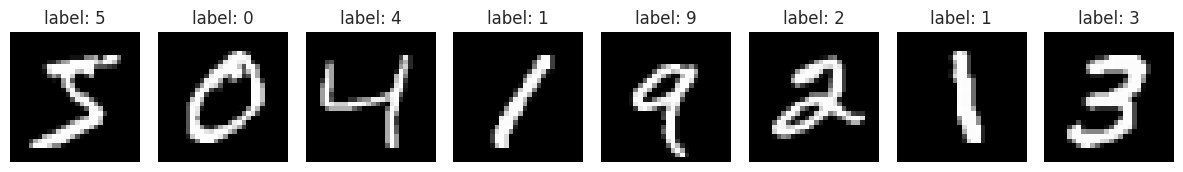

In [9]:
fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for ax, img, label in zip(axes, X_all[:8], y_all[:8]):
    ax.imshow(img, cmap="gray")
    ax.set_title(f"label: {label.item()}")
    ax.axis("off")
plt.tight_layout()
plt.show()

### Train / validation / test split

To keep the lab fast we work with a **subset** of the training data. Everything below works
identically on the full 60,000 images — it would just take longer to train. ⏱️

In [10]:
X_train, y_train = X_all[:10000],       y_all[:10000]
X_val,   y_val   = X_all[10000:12000],  y_all[10000:12000]
X_test,  y_test  = X_test_full,         y_test_full          # full 10k test set

# Wrap tensors into DataLoaders (mini-batches)
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=64, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val,   y_val),   batch_size=256)

print("train:", X_train.shape[0], "| val:", X_val.shape[0], "| test:", X_test.shape[0])

train: 10000 | val: 2000 | test: 10000


### 🌳 Baseline first: is a neural network even worth it?

Before deep learning, let's see how a **plain Decision Tree** does. A baseline tells us whether
the extra complexity of a neural network actually pays off.

In [11]:
# Decision trees need a flat feature vector -> reshape 28x28 into 784
tree = DecisionTreeClassifier(random_state=SEED)
tree.fit(X_train.reshape(-1, 28*28).numpy(), y_train.numpy())
tree_acc = accuracy_score(y_test.numpy(), tree.predict(X_test.reshape(-1, 28*28).numpy()))
print(f"Decision Tree test accuracy: {tree_acc:.3f}")

Decision Tree test accuracy: 0.809


### 🧠 Build the first architecture (`nn.Module`)

As requested, we use the **`nn.Module` class style** (the flexible, "grown-up" way to define
networks). Notice the ingredients you asked to keep:

- **multiple hidden layers** (784 → 256 → 128 → 10),
- **`ReLU`** activations,
- **`Dropout`** for regularisation (randomly "switches off" neurons during training).

> 💡 The output layer has **10 neurons** (one per digit) and **no softmax inside the model**.
> `nn.CrossEntropyLoss` expects raw **logits** and applies the softmax internally — cleaner and
> numerically more stable.

In [21]:
class MnistMLPFirst(nn.Module):
    def __init__(self, n_classes=10, p_drop=0.2):
        super().__init__()                       # required first line
        self.flatten = nn.Flatten()              # [B, 28, 28] -> [B, 784]
        self.fc1     = nn.Linear(28*28, 256)     # hidden layer 1
        self.fc2     = nn.Linear(256, 128)       # hidden layer 2
        self.out     = nn.Linear(128, n_classes) # 10 output neurons (logits)
        self.dropout = nn.Dropout(p_drop)

    def forward(self, x):
        x = self.flatten(x)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = torch.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.out(x)                          # raw logits, NO softmax here
        return x

model_01 = MnistMLPFirst().to(device)
torchinfo.summary(model_01, input_size=(1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
MnistMLPFirst                            [1, 10]                   --
├─Flatten: 1-1                           [1, 784]                  --
├─Linear: 1-2                            [1, 256]                  200,960
├─Dropout: 1-3                           [1, 256]                  --
├─Linear: 1-4                            [1, 128]                  32,896
├─Dropout: 1-5                           [1, 128]                  --
├─Linear: 1-6                            [1, 10]                   1,290
Total params: 235,146
Trainable params: 235,146
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.24
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.94
Estimated Total Size (MB): 0.95

#### ⚖️ Loss, optimizer & training

The **optimizer** (`Adam`) and the **training loop** are the same as always. Only the **loss**
is task-specific: `CrossEntropyLoss` for classification.

In [22]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_01.parameters(), lr=1e-3)

history = train_model(model_01, train_loader, val_loader, criterion, optimizer, n_epochs=15)

epoch   1/15  train_loss=0.7392  val_loss=0.3120
epoch   2/15  train_loss=0.3000  val_loss=0.2342
epoch   3/15  train_loss=0.2172  val_loss=0.2050
epoch   4/15  train_loss=0.1729  val_loss=0.1789
epoch   5/15  train_loss=0.1333  val_loss=0.1649
epoch   6/15  train_loss=0.1138  val_loss=0.1685
epoch   7/15  train_loss=0.0916  val_loss=0.1506
epoch   8/15  train_loss=0.0744  val_loss=0.1421
epoch   9/15  train_loss=0.0651  val_loss=0.1334
epoch  10/15  train_loss=0.0601  val_loss=0.1445
epoch  11/15  train_loss=0.0470  val_loss=0.1415
epoch  12/15  train_loss=0.0356  val_loss=0.1500
epoch  13/15  train_loss=0.0331  val_loss=0.1532
epoch  14/15  train_loss=0.0338  val_loss=0.1609
epoch  15/15  train_loss=0.0253  val_loss=0.1623


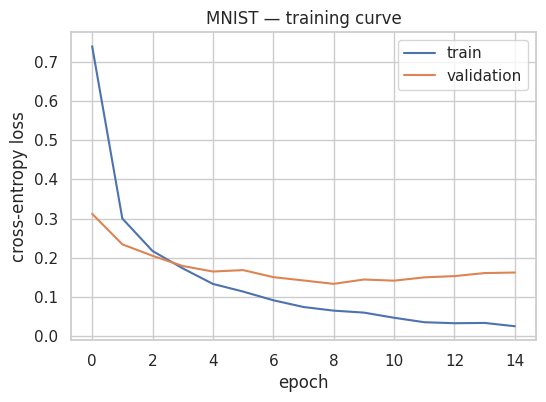

In [25]:
plt.figure(figsize=(6, 4))
plt.plot(history["train_loss"], label="train")
plt.plot(history["val_loss"],   label="validation")
plt.xlabel("epoch")
plt.ylabel("cross-entropy loss")
plt.title("MNIST — training curve")
plt.legend()
plt.show()

#### 📊 Evaluation

To turn logits into a predicted class we apply **`softmax`** (→ probabilities) and take the
**`argmax`** (→ the most likely digit).

In [26]:
model_01.eval()
with torch.no_grad():
    logits = model_01(X_test.to(device))
    probs  = torch.softmax(logits, dim=1)   # logits -> probabilities that sum to 1
    preds  = probs.argmax(dim=1).cpu()      # pick the most likely class

In [27]:
print(probs[0])

tensor([1.4424e-10, 1.1582e-08, 8.2224e-07, 3.5640e-05, 4.1087e-14, 7.8486e-11,
        3.0934e-15, 9.9996e-01, 5.5246e-10, 1.4920e-08])


In [28]:
print(preds[0])

tensor(7)


In [29]:
nn_acc = accuracy_score(y_test.numpy(), preds.numpy())
print(f"Neural network test accuracy: {nn_acc:.3f}")
print(f"Decision Tree  test accuracy: {tree_acc:.3f}   <- baseline")

Neural network test accuracy: 0.956
Decision Tree  test accuracy: 0.809   <- baseline


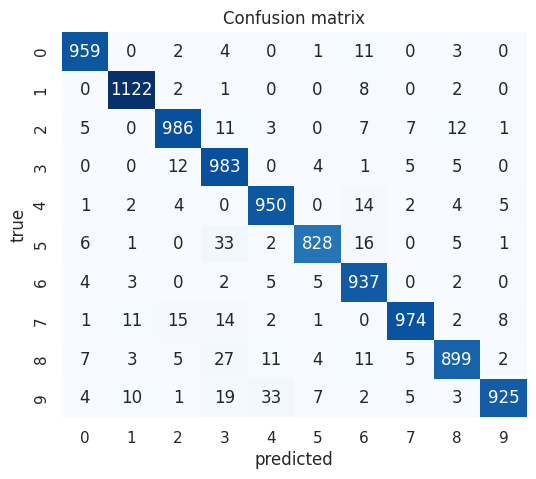

In [30]:
cm = confusion_matrix(y_test.numpy(), preds.numpy())
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("predicted"); plt.ylabel("true"); plt.title("Confusion matrix")
plt.show()

📌 **Overfitting & the role of Dropout**

A network with many parameters can **memorise** the training data instead of **learning** the
pattern — that is **overfitting**. You spot it when the **training loss keeps dropping** but the
**validation loss stops improving (or rises)**: a widening gap between the two curves.

### 🧠 Build the second architecture

In [57]:
class MnistMLPMish(nn.Module):
    def __init__(self, n_classes=10, p_drop=0.2):
        super().__init__()                       # required first line
        self.flatten = nn.Flatten()              # [B, 28, 28] -> [B, 784]
        self.fc1     = nn.Linear(28*28, 128)     # hidden layer 1
        self.fc2     = nn.Linear(128, 64)        # hidden layer 2
        self.fc3     = nn.Linear(64, 32)         # hidden layer 3
        self.out     = nn.Linear(32, n_classes) # 10 output neurons (logits)
        self.dropout = nn.Dropout(p_drop)

    def forward(self, x):
        x = self.flatten(x)
        x = F.mish(self.fc1(x))
        x = self.dropout(x)
        x = F.mish(self.fc2(x))
        x = self.dropout(x)
        x = F.mish(self.fc3(x))
        x = self.dropout(x)
        x = self.out(x)                          # raw logits, NO softmax here
        return x

model_02 = MnistMLPMish().to(device)
torchinfo.summary(model_02, input_size=(1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
MnistMLPMish                             [1, 10]                   --
├─Flatten: 1-1                           [1, 784]                  --
├─Linear: 1-2                            [1, 128]                  100,480
├─Dropout: 1-3                           [1, 128]                  --
├─Linear: 1-4                            [1, 64]                   8,256
├─Dropout: 1-5                           [1, 64]                   --
├─Linear: 1-6                            [1, 32]                   2,080
├─Dropout: 1-7                           [1, 32]                   --
├─Linear: 1-8                            [1, 10]                   330
Total params: 111,146
Trainable params: 111,146
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.11
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.44
Estimated Total Size (MB): 0.45

In [58]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_02.parameters(), lr=1e-3)

history = train_model(model_02, train_loader, val_loader, criterion, optimizer, n_epochs=15)

epoch   1/15  train_loss=1.0313  val_loss=0.4029
epoch   2/15  train_loss=0.4506  val_loss=0.3117
epoch   3/15  train_loss=0.3532  val_loss=0.2582
epoch   4/15  train_loss=0.2850  val_loss=0.2275
epoch   5/15  train_loss=0.2307  val_loss=0.1961
epoch   6/15  train_loss=0.2019  val_loss=0.1862
epoch   7/15  train_loss=0.1758  val_loss=0.1736
epoch   8/15  train_loss=0.1458  val_loss=0.1728
epoch   9/15  train_loss=0.1345  val_loss=0.1578
epoch  10/15  train_loss=0.1187  val_loss=0.1628
epoch  11/15  train_loss=0.1069  val_loss=0.1563
epoch  12/15  train_loss=0.0889  val_loss=0.1717
epoch  13/15  train_loss=0.0892  val_loss=0.1553
epoch  14/15  train_loss=0.0696  val_loss=0.1488
epoch  15/15  train_loss=0.0687  val_loss=0.1528


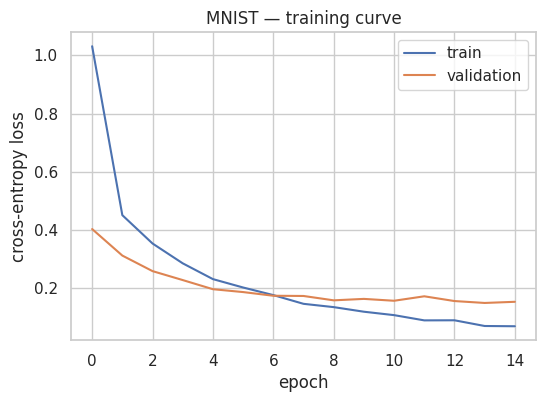

In [59]:
plt.figure(figsize=(6, 4))
plt.plot(history["train_loss"], label="train")
plt.plot(history["val_loss"],   label="validation")
plt.xlabel("epoch")
plt.ylabel("cross-entropy loss")
plt.title("MNIST — training curve")
plt.legend()
plt.show()

In [60]:
model_02.eval()
with torch.no_grad():
    logits = model_02(X_test.to(device))
    probs  = torch.softmax(logits, dim=1)
    preds  = probs.argmax(dim=1).cpu()

In [61]:
nn_acc = accuracy_score(y_test.numpy(), preds.numpy())
print(f"Neural network test accuracy: {nn_acc:.3f}")

Neural network test accuracy: 0.956


# 📈 Part 2 — Regression: Auto MPG

Now the **same machinery**, but predicting a **number** instead of a class. The dataset describes
1970s–80s cars; we predict **`mpg`** (miles per gallon) from features like horsepower, weight,
and number of cylinders.

Watch how little changes: the training loop and `nn.Module` skeleton are the same — only the
**output layer**, **loss**, and **metric** differ (remember the table 🎯).

In [62]:
url = 'https://raw.githubusercontent.com/rasvob/VSB-FEI-Deep-Learning-Exercises/main/datasets/auto-mpg.csv'
df = pd.read_csv(url, na_values='?', sep=';')   # '?' marks missing values
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


In [63]:
# A few rows have a missing horsepower -> drop them (only a handful)
print("missing values before:\n", df.isna().sum()[df.isna().sum() > 0])
df = df.loc[~df.horsepower.isna(), :].copy()

missing values before:
 horsepower    6
dtype: int64


### 🏷️ Handling categorical features
`origin` is a **category** (1=USA, 2=Europe, 3=Japan), not a real number, so we **one-hot encode**
it. `car_name` has too many unique values to be useful here, so we drop it. 🚗

In [64]:
df = df.drop('car_name', axis=1)
df['origin'] = df['origin'].replace({1: 'USA', 2: 'EUR', 3: 'JAP'})
df = pd.get_dummies(df, columns=['origin'], prefix='origin', dtype=float)  # -> origin_USA / origin_EUR / origin_JAP
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin_EUR,origin_JAP,origin_USA
0,18.0,8,307.0,130.0,3504.0,12.0,70,0.0,0.0,1.0
1,15.0,8,350.0,165.0,3693.0,11.5,70,0.0,0.0,1.0
2,18.0,8,318.0,150.0,3436.0,11.0,70,0.0,0.0,1.0
3,16.0,8,304.0,150.0,3433.0,12.0,70,0.0,0.0,1.0
4,17.0,8,302.0,140.0,3449.0,10.5,70,0.0,0.0,1.0


In [66]:
X = df.drop('mpg', axis=1).values.astype('float32')   # features
y = df['mpg'].values.astype('float32')                # target (a real number)

# train / val / test split (60 / 20 / 20)
X_tmp, X_test, y_tmp, y_test = train_test_split(X, y, test_size=0.2, random_state=13)
X_train,  X_val, y_train, y_val = train_test_split(X_tmp, y_tmp, test_size=0.25, random_state=13)
print("train:", X_train.shape, "| val:", X_val.shape, "| test:", X_test.shape)

train: (234, 9) | val: (79, 9) | test: (79, 9)


### 🔄 Why we must scale the features

Look at the raw features: `weight` is in the **thousands**, `model_year` is around **75**,
`cylinders` is **4–8**. These wildly different **magnitudes** make gradient descent unstable and
slow. We fix it with **`StandardScaler`** (mean 0, std 1) — fitted on the **training set only**,
then applied to val/test.

In [68]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [69]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1).to(device)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).reshape(-1, 1).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1).to(device)

train_loader_r = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=32, shuffle=True)
val_loader_r   = DataLoader(TensorDataset(X_val_tensor, y_val_tensor), batch_size=32)

### 📏 Baseline: Linear Regression
For regression the classic baseline is **linear regression**. If our network can't beat a straight
line, it isn't earning its keep.

In [70]:
lin = LinearRegression().fit(X_train, y_train)
lin_pred = lin.predict(X_test)
print(f"Linear Regression  ->  MAE: {mean_absolute_error(y_test, lin_pred):.2f} mpg | R2: {r2_score(y_test, lin_pred):.3f}")

Linear Regression  ->  MAE: 2.94 mpg | R2: 0.761


### 🧠 Build the regressor — spot the difference!

Compare this class with `MnistMLPFirst`. The **hidden part is the same idea** (Linear + ReLU +
Dropout). **Three things change**:

1. the **output layer** has **1 neuron** (we predict one number),
2. there is **no activation** on the output (a *linear* output can produce any real value),
3. we will use **`nn.MSELoss`** instead of `CrossEntropyLoss`.

In [73]:
class MpgMLP(nn.Module):
    def __init__(self, n_features, p_drop=0.1):
        super().__init__()
        self.fc1     = nn.Linear(n_features, 64)
        self.fc2     = nn.Linear(64, 32)
        self.out     = nn.Linear(32, 1)      # 1 output neuron
        self.dropout = nn.Dropout(p_drop)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = torch.relu(self.fc2(x))
        x = self.out(x)                      # NO activation -> real-valued output
        return x

model_reg = MpgMLP(n_features=X_train_tensor.shape[1]).to(device)
torchinfo.summary(model_reg, input_size=(1, X_train_tensor.shape[1]))

Layer (type:depth-idx)                   Output Shape              Param #
MpgMLP                                   [1, 1]                    --
├─Linear: 1-1                            [1, 64]                   640
├─Dropout: 1-2                           [1, 64]                   --
├─Linear: 1-3                            [1, 32]                   2,080
├─Linear: 1-4                            [1, 1]                    33
Total params: 2,753
Trainable params: 2,753
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.01
Estimated Total Size (MB): 0.01

In [74]:
criterion = nn.MSELoss()                               # regression loss
optimizer = torch.optim.Adam(model_reg.parameters(), lr=1e-2)

history_reg = train_model(model_reg, train_loader_r, val_loader_r, criterion, optimizer, n_epochs=100)

epoch  10/100  train_loss=10.6417  val_loss=6.2826
epoch  20/100  train_loss=8.9538  val_loss=8.1852
epoch  30/100  train_loss=8.8851  val_loss=6.5740
epoch  40/100  train_loss=8.5729  val_loss=5.7056
epoch  50/100  train_loss=6.9035  val_loss=8.4161
epoch  60/100  train_loss=8.9683  val_loss=8.8545
epoch  70/100  train_loss=8.1028  val_loss=7.4352
epoch  80/100  train_loss=7.2357  val_loss=5.0332
epoch  90/100  train_loss=7.3149  val_loss=6.2553
epoch 100/100  train_loss=7.0036  val_loss=5.1195


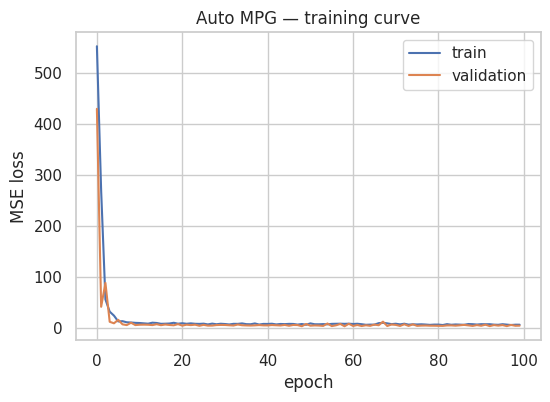

In [75]:
plt.figure(figsize=(6, 4))
plt.plot(history_reg["train_loss"], label="train")
plt.plot(history_reg["val_loss"],   label="validation")
plt.xlabel("epoch"); plt.ylabel("MSE loss"); plt.title("Auto MPG — training curve")
plt.legend(); plt.show()

### 📊 Regression metrics
There is no "accuracy" for numbers. Instead we measure **how far off** the predictions are:

- **MAE** — mean absolute error (average miss, in mpg) — easy to interpret.
- **RMSE** — root mean squared error — punishes big misses more.
- **$R^2$** — fraction of variance explained (1.0 = perfect, 0 = no better than predicting the mean).

In [76]:
model_reg.eval()
with torch.no_grad():
    y_pred = model_reg(X_test_tensor.to(device)).cpu().numpy().ravel()

mae  = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2   = r2_score(y_te, y_pred)
print(f"Neural network    ->  MAE: {mae:.2f} mpg | RMSE: {rmse:.2f} | R2: {r2:.3f}")
print(f"Linear Regression ->  MAE: {mean_absolute_error(y_test, lin_pred):.2f} mpg | R2: {r2_score(y_test, lin_pred):.3f}   <- baseline")

Neural network    ->  MAE: 2.30 mpg | RMSE: 3.12 | R2: 0.828
Linear Regression ->  MAE: 2.94 mpg | R2: 0.761   <- baseline


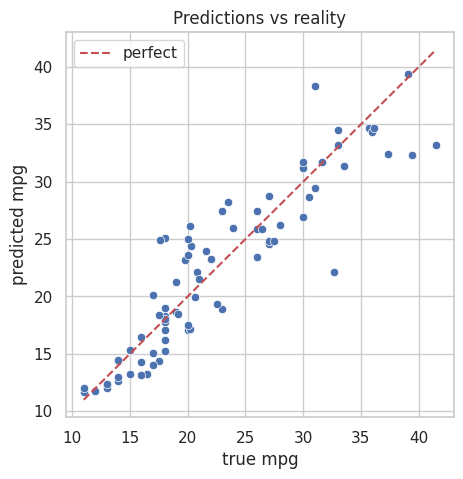

In [77]:
# Predictions vs reality: perfect predictions would lie on the diagonal
plt.figure(figsize=(5, 5))
sns.scatterplot(x=y_test, y=y_pred)
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, 'r--', label="perfect")
plt.xlabel("true mpg"); plt.ylabel("predicted mpg"); plt.title("Predictions vs reality")
plt.legend(); plt.show()

# Activities ✏️

Now it's your turn. The cells below are **starting points** — read the hint, edit the code, re-run,
and observe. Aim to complete **at least three**.

## Activity 1 — Change the architecture 🏗️

Take **one** of the two networks — the **regressor**  *or* the **classifier** — and experiment with its architecture. Try changes below and compare the metric against the original.

1. **Hidden layer size** — make a layer wider or narrower.
2. **Number of layers** — add more hidden layers.
3. **Activation function** — replace `torch.relu` with another activation function.

For each variant, also look at the **model size** — the number of trainable parameters. Compare **size vs. metric**: does a bigger model actually predict better here, or just cost more parameters? 📊

## Activity 2 — Tune the Dropout rate 🎛️

Take **one** of the two networks — the **classifier** or the **regressor**  — and try `p_drop` values of `0.0`, `0.5`, `0.8`. Rebuild and retrain the model for each value, then plot the **train vs. validation** loss curves.

Which value keeps the train and validation curves **closest together**? What happens when dropout is **too high**?

## Activity 3 — Break it on purpose: the output-activation trap ☣️
Scale the target `mpg` into `(0, 1)` and add a **`sigmoid`** to the output of the regressor.
Train it — the predictions will be badly capped. Then **remove the sigmoid** (linear output) and
watch it recover. This shows why the output activation must match your target range.

## Activity 4 — Transform the target with PowerTransformer 🎯

Try to use `PowerTransformer` for the output values in a similar manner as the `MinMaxScaler`.

- When do we use it? Why?
- If you wanted to guess if it helps, what do you think?
    - Plot a histogram of the output (`mpg`), you can make an educated guess based on it 😋

> 💡 Retrain `MpgMLP`, then
> `inverse_transform` the predictions back before scoring. Keep the output **linear**.